In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
product_category = pd.read_csv("../../data/raw/product_category_name_translation.csv")

In [5]:
product_category

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [6]:
product_category.info()
product_category.isnull().sum()
product_category["product_category_name"].nunique()
product_category["product_category_name"].duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


np.int64(0)

In [7]:
products = pd.read_csv("../../data/raw/olist_products_dataset.csv")
order_items = pd.read_csv("../../data/raw/olist_order_items_dataset.csv")

category_products = products.merge(
    product_category,
    on="product_category_name",
    how="left"
)

category_items = order_items.merge(
    category_products[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

category_products["product_category_name_english"].isnull().sum()

np.int64(623)

In [8]:
product_count_by_category = (
    category_products["product_category_name_english"]
    .value_counts()
    .head(15)
)

item_count_by_category = (
    category_items["product_category_name_english"]
    .value_counts()
    .head(15)
)

product_count_by_category

product_category_name_english
bed_bath_table              3029
sports_leisure              2867
furniture_decor             2657
health_beauty               2444
housewares                  2335
auto                        1900
computers_accessories       1639
toys                        1411
watches_gifts               1329
telephony                   1134
baby                         919
perfumery                    868
stationery                   849
fashion_bags_accessories     849
cool_stuff                   789
Name: count, dtype: int64

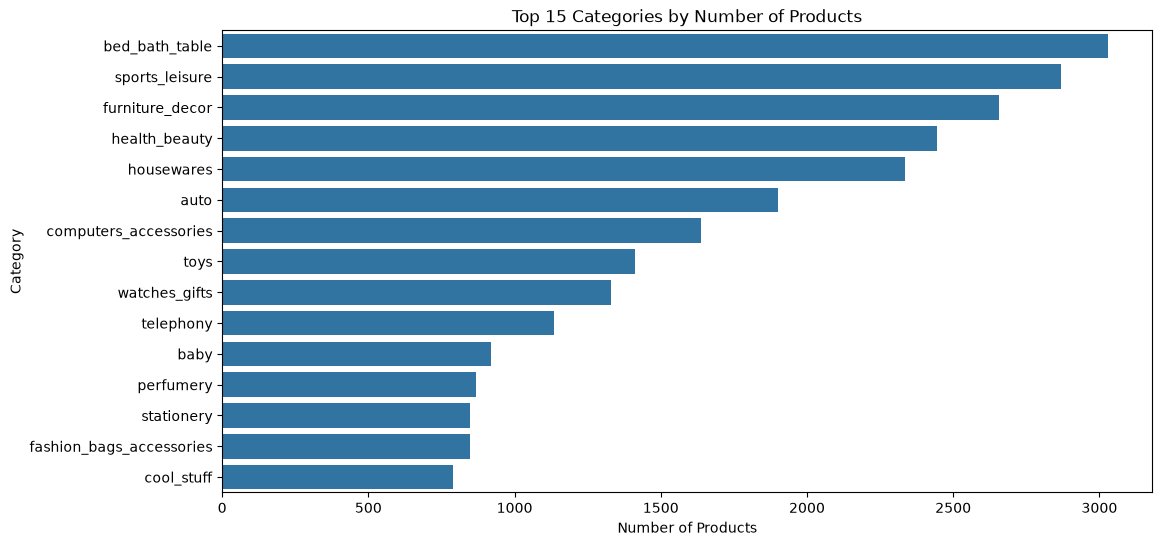

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(x=product_count_by_category.values, y=product_count_by_category.index)
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.title("Top 15 Categories by Number of Products")
plt.savefig("../../output/charts/product_category/top_categories_by_products.png", dpi=300)
plt.show()

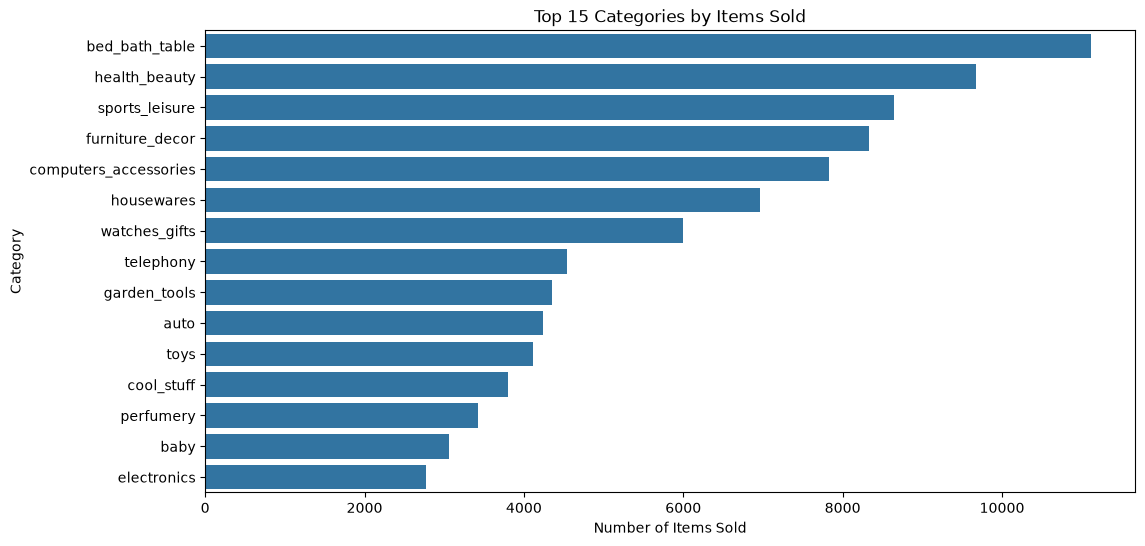

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(x=item_count_by_category.values, y=item_count_by_category.index)
plt.xlabel("Number of Items Sold")
plt.ylabel("Category")
plt.title("Top 15 Categories by Items Sold")
plt.savefig("../../output/charts/product_category/top_categories_by_items_sold.png", dpi=300)
plt.show()

In [11]:
sales_by_category = (
    category_items
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

sales_by_category

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
toys                      483946.60
baby                      411764.89
perfumery                 399124.87
telephony                 323667.53
office_furniture          273960.70
Name: price, dtype: float64

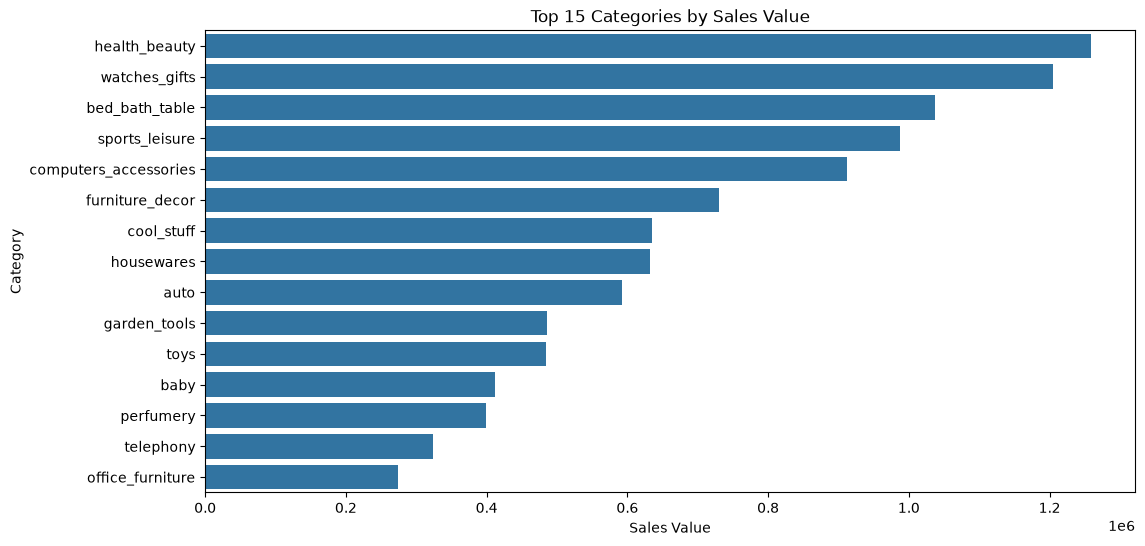

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(x=sales_by_category.values, y=sales_by_category.index)
plt.xlabel("Sales Value")
plt.ylabel("Category")
plt.title("Top 15 Categories by Sales Value")
plt.savefig("../../output/charts/product_category/top_categories_by_sales.png", dpi=300)
plt.show()

## Key Observations

### 1. Category Translation Data

- The translation file contains **71 product categories**.
- The category names are available in both Portuguese and English, which makes the product analysis easier to understand.
- The category names do not contain duplicate Portuguese entries.

### 2. Product Categories in the Catalog

- The catalog contains products from many different categories.
- **Bed bath table** has the largest number of products, followed by **sports leisure**, **furniture decor**, and **health beauty**.
- Product availability is concentrated in a small number of popular categories.

### 3. Missing Category Translations

- **623 products** do not have a matching English category after the merge.
- These missing values are likely related to products with missing original category names or categories that are not included in the translation file.
- These products should be kept in mind when interpreting category totals.

### 4. Items Sold by Category

- The number of listed products and the number of items sold are not necessarily the same.
- A category with fewer listed products can still have strong sales if its products are purchased more frequently.
- Comparing product count with items sold gives a better understanding of category activity.

### 5. Sales Value by Category

- **Health beauty** has the highest sales value, followed by **watches gifts** and **bed bath table**.
- **Sports leisure** and **computers accessories** also have high sales values.
- The category with the most products is not the same as the category with the highest sales value, showing that catalog size alone does not determine sales performance.

### Overall Insight

Overall, the product categories show that a few areas contribute strongly to the marketplace. Bed bath table has the largest product catalog, while health beauty and watches gifts generate the highest sales value. Category translations make the results easier to interpret, but missing category information should be considered when comparing totals.